### This notebook covers (needs cleaning up...)
1. Getting UVW from baselines in ENU and source in AltAz, and baselines in ITRS and source in HA/Dec (this is very often confusing and I havent seen this derived explicitly before.)
2. Rotation synthesis

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import EarthLocation, SkyCoord, AltAz,TETE
from astropy.time import Time
import radio_tools as rt
import astropy.units as u
from scipy.fft import next_fast_len

Now that we're familiar with fringes, let's actually compute the UV coverage for the array.
Remember that UV plane is defined in the direction of the source.

In [9]:
hera = np.genfromtxt(
    "hera_ant_pos.csv",
    delimiter=",",
    names=True,
    dtype=None,
    encoding="utf-8"
)
hera_xyz = np.asarray([hera['x'],hera['y'],hera['z']]).T.copy() # xyz along columns
hera_ref = EarthLocation.from_geodetic(lat='−30.72152612068925°', lon='21.42830382686301°',height='1051.69 m')
hera_enu = rt.itrs_to_enu(hera_xyz, hera_ref.lat.deg, hera_ref.lon.deg)
nant = hera_xyz.shape[0]
ix = np.triu_indices(nant,k=1)
hera_bl_enu = hera_enu[ix[1]]-hera_enu[ix[0]]

tstart = 1753200150 #random datetime, you can choose your favorite, just make sure the source is risen!
obstime=Time(tstart,format="unix",scale="utc")
cenA = SkyCoord(ra='13h 25m 27.6150s',dec='−43° 01′ 08.806″', frame='icrs') 
azalt_cenA = cenA.transform_to(AltAz(location=hera_ref,obstime=obstime))
print("new az alt", azalt_cenA.az.deg, azalt_cenA.alt.deg)

new az alt 183.29482826319708 77.54182223021188


In [10]:
# Let's say it's operating at 150 MHz, and each dish is 14 m wide.
# what's the FoV of one dish, and what's the rough resolution of the array?
nu=150e6
lm = 3e8/nu #m
d = 14 #m dish size
max_bl = np.max(np.sqrt(np.sum(hera_bl_enu**2,axis=1)))
res = lm/max_bl #max baseline
fov = lm/d

print(f"Synth. beam res\t: {np.rad2deg(res)*60:4.2f} arcmin\nFOV\t\t: {np.rad2deg(fov):4.2f} deg")

Synth. beam res	: 7.84 arcmin
FOV		: 8.19 deg


In [80]:
#Projecting baseline in ENU to uvw where w is along the source. I will build the change of basis matrix explicitly
sin_az = np.sin(azalt_cenA.az.rad)
cos_az = np.cos(azalt_cenA.az.rad)
sin_alt = np.sin(azalt_cenA.alt.rad)
cos_alt = np.cos(azalt_cenA.alt.rad)

W_enu = np.asarray([sin_az*cos_alt, cos_az*cos_alt, sin_alt]) 

# NCP is true North tilted up by Latitude (Z-axis)
lat_rad = hera_ref.lat.rad
NCP_enu = np.array([0, np.cos(lat_rad), np.sin(lat_rad)])

# Standard astronomical U is orthogonal to NCP and W
U_enu = np.cross(NCP_enu, W_enu)
U_enu /= np.linalg.norm(U_enu) # Normalize

V_enu = np.cross(W_enu, U_enu)

mat1 = np.vstack([U_enu, V_enu, W_enu]).T
hera_uvw1 = hera_bl_enu @ mat1 / lm


Text(0, 0.5, 'V (wavelengths)')

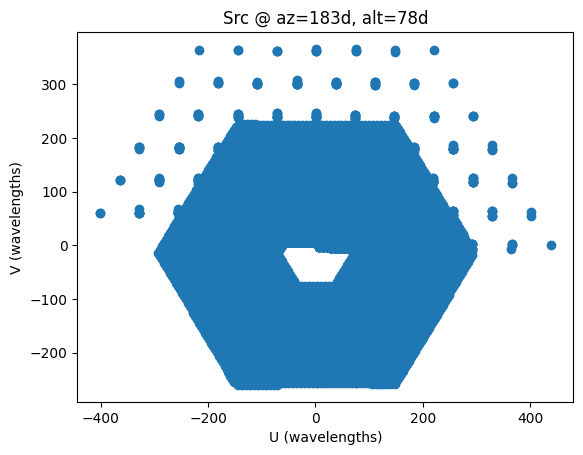

In [81]:
plt.scatter(hera_uvw1[:,0], hera_uvw1[:,1])
plt.title(f"Src @ az={azalt_cenA.az.deg:.0f}d, alt={azalt_cenA.alt.deg:.0f}d")
plt.xlabel("U (wavelengths)")
plt.ylabel("V (wavelengths)")

We want to image. Want to grid UV coverage onto a regular FFT grid.

What grid spacing in uv?
What size of grid?

Remember time-domain examples. Frequency resolution is the 1/longest timescale you measure. And total extent (-ve to +ve) in frequency is the 1/smallest timescale you measure = sampling rate. Same idea but our fourier duals are pixels of the image on the sky and uv points on the UV plane.

Grid spacing $\Delta u$ set by the patch size we want to image ~ 1/full-width of primary beam.

Grid size $u_{max}$ set by the image resolution we want ~ 1/synthesized beam.

In [60]:
def grid_uv(uv,du,npix):
    
    S = np.zeros((npix,npix),dtype='float64')
    uv_int = np.round(uv/du).astype(int)
    for i in range(uv.shape[0]):
        S[uv_int[i,0],uv_int[i,1]] +=1
        #image is a real field. So it's FFT must be hermitian symmetric
        S[-uv_int[i,0],-uv_int[i,1]] +=1
    return S

In [66]:
du=1/fov
umax=1/res
npix = int(fov/res)
#it's generally better to over-sample the image to avoid pixelization effects. Rule of thumb is 3 pixels per beamwidth.
npix *= 3
img_res = res/3
gridded_uv = grid_uv(hera_uvw[:,:2], du, npix)

In [92]:
img = np.fft.ifft2(gridded_uv).real

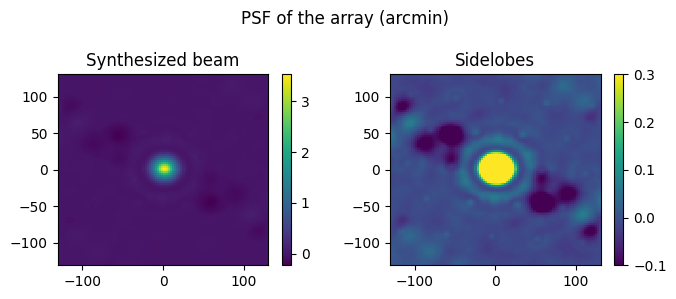

In [105]:
width=50 #pix
patch=slice(npix//2-width,npix//2+width)
extent = [-np.rad2deg(width*img_res)*60, np.rad2deg(width*img_res)*60, -np.rad2deg(width*img_res)*60, np.rad2deg(width*img_res)*60]
f=plt.gcf()
plt.suptitle("PSF of the array (arcmin)")
f.set_size_inches(7,3)
plt.subplot(121)
plt.title("Synthesized beam")
im=plt.imshow(np.fft.fftshift(img)[patch,patch],aspect='auto',interpolation='none',origin='lower',extent=extent)
plt.colorbar(ax=plt.gca())
plt.subplot(122)
plt.title("Sidelobes")
im=plt.imshow(np.fft.fftshift(img)[patch,patch],aspect='auto',interpolation='none',vmax=0.3,vmin=-0.1,origin='lower',extent=extent)
plt.colorbar(ax=plt.gca())
plt.tight_layout()

### What happens when the source is really low in the sky?

new az alt 222.11984250452292 5.53945633698941


Text(0, 0.5, 'V (wavelengths)')

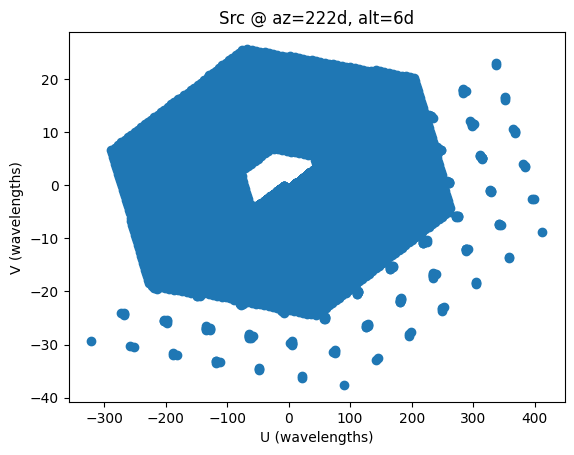

In [114]:
tstart = 1753200150 + 27000
obstime=Time(tstart,format="unix",scale="utc")
azalt_cenA = cenA.transform_to(AltAz(location=hera_ref,obstime=obstime))
print("new az alt", azalt_cenA.az.deg, azalt_cenA.alt.deg)
sin_az = np.sin(azalt_cenA.az.rad)
cos_az = np.cos(azalt_cenA.az.rad)
sin_alt = np.sin(azalt_cenA.alt.rad)
cos_alt = np.cos(azalt_cenA.alt.rad)
W= [sin_az*cos_alt, cos_az*cos_alt, sin_alt] #components of w in ENU, this is the direction of the source!
U= [cos_az, -sin_az, 0] #east rotates by azimuth
V = np.cross(W,U)
mat = np.vstack([U,V,W]).T
hera_uvw = hera_bl_enu@mat/lm
plt.scatter(hera_uvw[:,0], hera_uvw[:,1])
plt.title(f"Src @ az={azalt_cenA.az.deg:.0f}d, alt={azalt_cenA.alt.deg:.0f}d")
plt.xlabel("U (wavelengths)")
plt.ylabel("V (wavelengths)")

Severe baseline forshortening in NS direction because of how low the source is. Since it's at approx near local south (180 d azimuth), EW baseline isnt too affected. But given how low it is (6 d alt), projected NS baseline is very short.

In [115]:
gridded_uv = grid_uv(hera_uvw[:,:2], du, npix)
img = np.fft.ifft2(gridded_uv).real

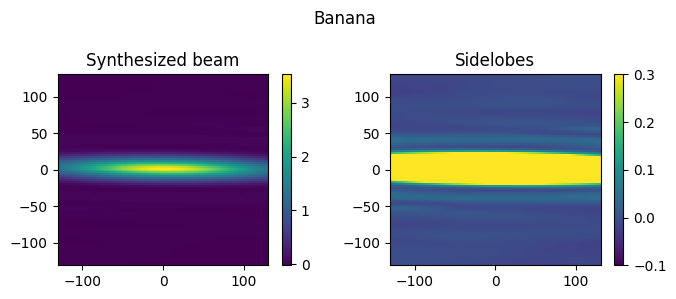

In [116]:
width=50 #pix
patch=slice(npix//2-width,npix//2+width)
extent = [-np.rad2deg(width*img_res)*60, np.rad2deg(width*img_res)*60, -np.rad2deg(width*img_res)*60, np.rad2deg(width*img_res)*60]
f=plt.gcf()
plt.suptitle("Banana")
f.set_size_inches(7,3)
plt.subplot(121)
plt.title("Synthesized beam")
im=plt.imshow(np.fft.fftshift(img)[patch,patch],aspect='auto',interpolation='none',origin='lower',extent=extent)
plt.colorbar(ax=plt.gca())
plt.subplot(122)
plt.title("Sidelobes")
im=plt.imshow(np.fft.fftshift(img)[patch,patch],aspect='auto',interpolation='none',vmax=0.3,vmin=-0.1,origin='lower',extent=extent)
plt.colorbar(ax=plt.gca())
plt.tight_layout()

### Astropy altaz is too slow. how do I track source through the day?

In a topocentric frame both alt and az change as the source moves. But in a geocentric frame, the only change is in the longitudinal coordinate as the source moves.

Well...almost! You can absolutely go from topocentric to a geocentric Earth Centered Earth Fixed (ECEF) frame. But source position in ECEF is NOT the same as source in ICRS frame rotated along the north pole. The position of the source in say (HA,Dec) obtained directly from RA, Dec + longitudinal rotation will be slightly off compared to that obtained by AltAz->HA,Dec. 

This is because of the long chain of corrections it takes to go from source position ICRS to observed position in a topocentric system. Effects like parallax, annual abberation, deflection of light by the sun, Earth's precession and nutation, and polar motion (movement of Earth's crust.) These effects can contribute 10s of arcseconds, which matters when doing VLBI.

For our purposes, we will ignore all these effects and assume that Earth's axis is aligned with ICRS north celestial pole. Tracking a source then becomes easy.



In [85]:
#First get baselines in geocentric system (no ENU)
hera_bl_xyz = hera_xyz[ix[1]]-hera_xyz[ix[0]]

# Equation of Time: HA = ERA + lon - RA_apparent
# If we ignore preceession and nutation then RA_apparent = RA

tstart = 1753200150
obstime=Time(tstart,format="unix",scale="utc",location=hera_ref)
apparent_cenA = cenA.transform_to(TETE(obstime=obstime))
era = obstime.earth_rotation_angle() ##NOTE ASTROPY ALREADY includes longitude of location
ha = era.rad - cenA.ra.rad
print("Hour angle of Cen A (rad)", ha)

# SIDE NOTE
# Earth Rotation Angle which is defined to be linear with UT1 timescale. Much cleaner the Local Sidereal time.
# LST is defined wrt to a source, but having same rotation axis as ICRS. Position of ref source wobbles because of preccsion, so LST is not linear with UT1.

Hour angle of Cen A (rad) 0.017805551697328337


Now the same exact idea as before. Express source position in same coordinate system as the baselines and calculate dot products.

As a reminder X is greenwich, Z is north pole, and Hour Angle increases east to west. Sources have -ve HA before crossing your meridian and +ve HA after having crossed.

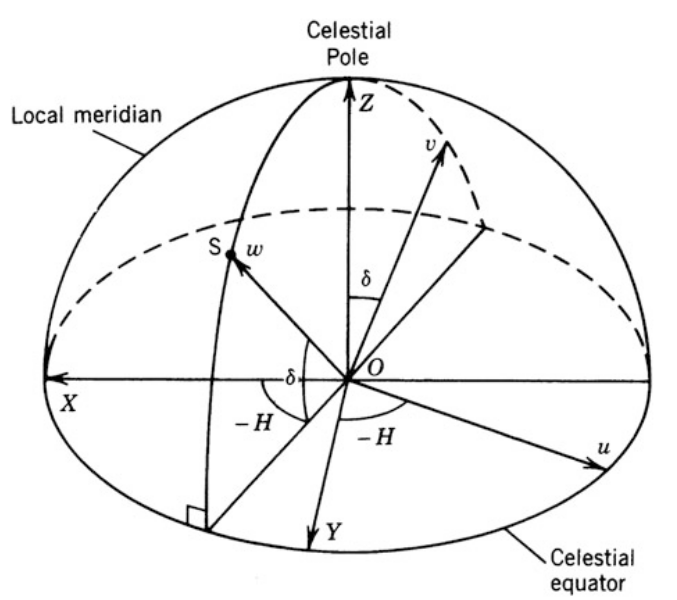

In [70]:
ha

np.float64(0.011269073718461087)

In [86]:
ha

np.float64(0.017805551697328337)

In [89]:
ha,dec = azalt_to_hadec(azalt_cenA.az.rad, azalt_cenA.alt.rad, hera_ref.lat.rad)
gha = ha - hera_ref.lon.rad #hour angle at Greenwich - 0.2
# dec = apparent_cenA.dec.rad
# dec = cenA.dec.rad
print(gha,dec)
sin_gha = np.sin(gha)
cos_gha = np.cos(gha)
sin_dec = np.sin(dec)
cos_dec = np.cos(dec)


W= np.asarray([cos_gha*cos_dec, -sin_gha*cos_dec, sin_dec])
U= np.asarray([sin_gha, cos_gha, 0])
V = np.cross(W,U)
mat = np.vstack([U,V,W]).T
hera_uvw2 = hera_bl_xyz@mat/lm


-0.3569974832047039 -0.7532076994182199


In [30]:
def hadec_to_azalt(ha, dec, lat):
    aa = np.sin(lat) * np.sin(dec) + np.cos(lat) * np.cos(dec) * np.cos(ha)
    aa[aa > 1] = 1
    aa[aa < -1] = -1
    alt = np.arcsin(aa)
    sin_az = -np.cos(dec) * np.sin(ha) / np.cos(alt)
    cos_az = (np.cos(lat) * np.sin(dec) - np.sin(lat) * np.cos(dec) * np.cos(ha)) / np.cos(alt)
    az = np.arctan2(sin_az, cos_az)
    az = (az + 2 * np.pi) % (2 * np.pi)
    return az, alt

def azalt_to_hadec(az, alt, lat):
    sinalt = np.sin(alt)
    cosalt = np.cos(alt)
    sinaz = np.sin(az)
    cosaz = np.cos(az)
    sinlat = np.sin(lat)
    coslat = np.cos(lat)

    sindec = sinalt * sinlat + cosalt * coslat * cosaz
    
    # Clip to strictly [-1, 1] to avoid NaN errors from floating point inaccuracies
    sindec = np.clip(sindec, -1.0, 1.0)
    dec = np.arcsin(sindec)

    y = -sinaz * cosalt
    x = sinalt * coslat - cosalt * sinlat * cosaz
    ha = np.arctan2(y, x)
    ha = ha % (2 * np.pi)
    return ha, dec

In [242]:
hadec_to_azalt(np.asarray([ha]), np.asarray([dec]), hera_ref.lat.rad)

(array([3.20261753]), array([1.35569568]))

In [76]:
azalt_to_hadec(azalt_cenA.az.rad, azalt_cenA.alt.rad, hera_ref.lat.rad)

(np.float64(0.016996971691756544), np.float64(-0.7532076994182199))

In [75]:
ha,dec

(np.float64(0.011269073718461087), np.float64(-0.7532075288439379))

In [234]:
azalt_cenA.az.rad, azalt_cenA.alt.rad

(np.float64(3.1990982550703486), np.float64(1.3533601059133298))

Text(0, 0.5, 'V (wavelengths)')

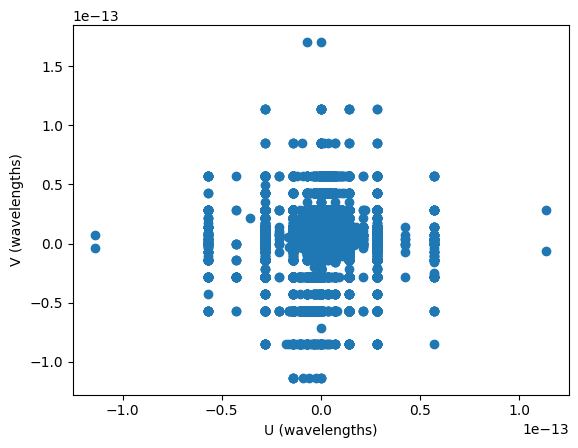

In [90]:
plt.scatter(hera_uvw2[:,0]-hera_uvw1[:,0], hera_uvw2[:,1]-hera_uvw1[:,1])
plt.xlabel("U (wavelengths)")
plt.ylabel("V (wavelengths)")

Text(0, 0.5, 'V (wavelengths)')

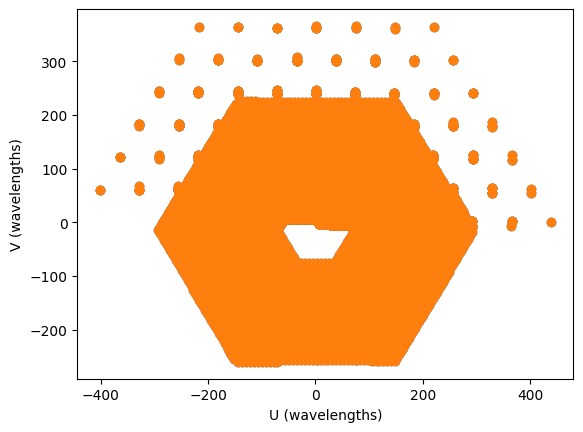

In [91]:
plt.scatter(hera_uvw1[:,0], hera_uvw1[:,1])
plt.scatter(hera_uvw2[:,0], hera_uvw2[:,1])
plt.xlabel("U (wavelengths)")
plt.ylabel("V (wavelengths)")